#### re-weighting samples

      search_trends_common_cold  stringency_index  \
0                     14.744286         79.630000   
1                     16.530000         64.418571   
2                     16.725714         87.960000   
3                     17.327143         82.410000   
4                     17.478571         78.700000   
...                         ...               ...   
6098                   8.902857         36.110000   
6099                  10.401429         33.330000   
6101                   9.917143         27.780000   
6102                   9.102857         30.951429   
6103                  10.294286         31.480000   

      new_persons_fully_vaccinated  average_temperature_celsius  inc cases  \
0                     62276.823478                    10.089947     2728.0   
1                     62276.823478                    14.730159     1374.0   
2                     62276.823478                     6.176367      362.0   
3                     62276.823478                 

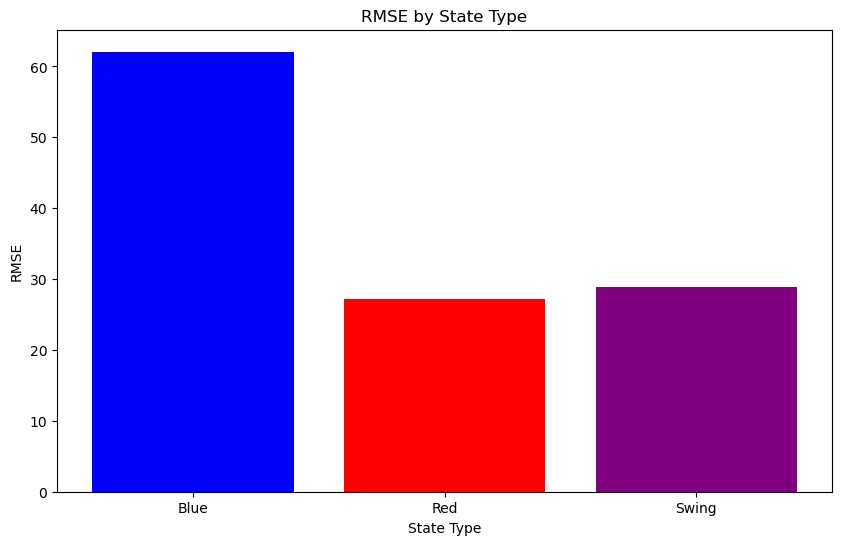

Random Forest AIC: 4332.7203
Test MAE: 10.6059
ANOVA F-value: 1.3788904752761186
p-value: 0.25273991470283796

Demographic Parity:
    State Type  Mean Predicted Value
0           0            194.044225
1           1            232.826481
2           2            240.900835

Equalized Odds (Residuals):
   State_Type  Mean Residual  Std Residual
0           0      -3.583024     62.126938
1           1       3.153843     27.017706
2           2      -4.427015     28.658261

Predictive Parity (Mean Absolute Error):
   State Type        MAE
0           0  11.763867
1           1   9.652407
2           2  10.352101

Data Points Count by State Type:
    State Type  Counts
0           1     226
1           0     210
2           2     109


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy.stats import f_oneway

# Load dataset
df = pd.read_csv('processed_data/100k_population_data.csv', low_memory=False)

# Exclude territories
territories_to_exclude = ['US_GU', 'US_VI', 'US_AS', 'US_PR', 'US_MP', 'US_DC']
df = df[~df['location_key'].isin(territories_to_exclude)]

# Define state lists
blue_states_list = ['US_CA', 'US_ME', 'US_OR', 'US_CO', 'US_MD', 'US_RI', 'US_CT', 'US_MA', 'US_VT', 'US_DE', 'US_NH', 'US_VA', 'US_NJ', 'US_WA', 'US_HI', 'US_NM', 'US_NY', 'US_IL']
red_states_list = ['US_AL', 'US_AK', 'US_AR', 'US_ID', 'US_IN', 'US_IA', 'US_KS', 'US_KY', 'US_LA', 'US_MS', 'US_MO', 'US_MT', 'US_NE', 'US_ND', 'US_OK', 'US_SC', 'US_SD', 'US_TN', 'US_TX', 'US_UT', 'US_WV', 'US_WY']
swing_states_list = ['US_AZ', 'US_NV', 'US_FL', 'US_NC', 'US_GA', 'US_OH', 'US_MI', 'US_PA', 'US_MN', 'US_WI']

# Create dummy variables for state types
df['blue_states'] = df['location_key'].apply(lambda x: 1 if x in blue_states_list else 0)
df['red_states'] = df['location_key'].apply(lambda x: 1 if x in red_states_list else 0)
df['swing_states'] = df['location_key'].apply(lambda x: 1 if x in swing_states_list else 0)

# Create a state_type column
def get_state_type(row):
    if row['blue_states'] == 1:
        return 'Blue'
    elif row['red_states'] == 1:
        return 'Red'
    elif row['swing_states'] == 1:
        return 'Swing'
    else:
        return 'Other'

df['state_type'] = df.apply(get_state_type, axis=1)

# Drop unneeded columns
columns_to_drop = ['blue_states', 'red_states', 'swing_states', 'target_end_date', 'location_key', 'location', 'new_hospitalized_patients', 'hospitalized_per_100k', 'unemployment_rate', 'year']
df = df.drop(columns=columns_to_drop)

# Impute missing values
df.fillna(df.mean(numeric_only=True), inplace=True)

# Display dataframe
print(df)

# Define encode_state_type function
def encode_state_type(state):
    if state == 'Blue':
        return 0
    elif state == 'Red':
        return 1
    else: 
        return 2 # For Swing states

# Encode state_type as a categorical feature
df['state_type_encoded'] = df['state_type'].apply(encode_state_type)

# Separate features and target variable
X = df.drop(columns=['cases_per_100k', 'state_type'])
y = df['cases_per_100k']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# Calculate sample weights
weights = X_train['state_type_encoded'].map({
    0: len(X_train) / X_train['state_type_encoded'].value_counts()[0],
    1: len(X_train) / X_train['state_type_encoded'].value_counts()[1],
    2: len(X_train) / X_train['state_type_encoded'].value_counts()[2]
})

# Initialize and train the Random Forest model with sample weights
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train, sample_weight=weights)

# Evaluate the model
y_pred = rf_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Cross-validation
cv = KFold(n_splits=5, random_state=42, shuffle=True)
cv_scores = cross_val_score(rf_model, X_train, y_train, cv=cv, scoring='neg_mean_squared_error', fit_params={'sample_weight': weights})
cv_rmse_scores = np.sqrt(-cv_scores)

# Print evaluation metrics
print(f'R2: {r2:.4f}')
print(f'Test RMSE: {rmse:.4f}')
print(f'Cross-Validation RMSE: {cv_rmse_scores.mean():.4f} (+/- {cv_rmse_scores.std():.4f})')

# Create DataFrame with actual and predicted values
y_test_df = pd.DataFrame({
    'cases_per_100k': y_test,  # Actual values
    'state_type': X_test['state_type_encoded'],  # Encoded state type
    'predicted': y_pred  # Predicted values
})

# Define a function to calculate RMSE
def calculate_rmse(group):
    return np.sqrt(mean_squared_error(group['cases_per_100k'], group['predicted']))

# Group by state type and calculate RMSE for each group
rmse_by_state_type = y_test_df.groupby('state_type').apply(calculate_rmse).reset_index()
rmse_by_state_type.columns = ['State Type', 'RMSE']

# Plot RMSE by State Type
plt.figure(figsize=(10, 6))
plt.bar(rmse_by_state_type['State Type'], rmse_by_state_type['RMSE'], color=['blue', 'red', 'purple'])
plt.xlabel('State Type')
plt.ylabel('RMSE')
plt.title('RMSE by State Type')
plt.xticks(ticks=[0, 1, 2], labels=['Blue', 'Red', 'Swing'])
plt.show()

# AIC calculation
n = len(y_test)
rss = np.sum((y_test - y_pred) ** 2)
k_rf = len(rf_model.estimators_) + 1
aic_rf = n * np.log(rss / n) + 2 * k_rf
print(f'Random Forest AIC: {aic_rf:.4f}')

# Additional model evaluation metrics
test_mae = mean_absolute_error(y_test, y_pred)
print(f'Test MAE: {test_mae:.4f}')

# ANOVA F-value and p-value
f_value, p_value = f_oneway(y_test_df[y_test_df['state_type'] == 0]['cases_per_100k'],
                             y_test_df[y_test_df['state_type'] == 1]['cases_per_100k'],
                             y_test_df[y_test_df['state_type'] == 2]['cases_per_100k'])
print("ANOVA F-value:", f_value)
print("p-value:", p_value)

# Demographic Parity
demographic_parity = y_test_df.groupby('state_type')['cases_per_100k'].mean().reset_index()
demographic_parity.columns = ['State Type', 'Mean Predicted Value']
print("\nDemographic Parity:\n", demographic_parity)

# Equalized Odds (Residuals)
# Calculate residuals
residuals = y_test - y_pred

# Create a DataFrame with residuals and state_type
results_df = pd.DataFrame({'Residuals': residuals, 'state_type': X_test['state_type_encoded']})

# Group by state_type and calculate mean and standard deviation of residuals
residuals_by_state_type = results_df.groupby('state_type').agg({'Residuals': [list, np.mean, np.std]}).reset_index()

# Rename columns for clarity
residuals_by_state_type.columns = ['State_Type', 'Residuals', 'Mean Residual', 'Std Residual']

print("\nEqualized Odds (Residuals):")
print(residuals_by_state_type[['State_Type', 'Mean Residual', 'Std Residual']])

# Predictive Parity (Mean Absolute Error)
mae_by_state_type = y_test_df.groupby('state_type').apply(lambda x: mean_absolute_error(x['cases_per_100k'], x['predicted'])).reset_index()
mae_by_state_type.columns = ['State Type', 'MAE']
print("\nPredictive Parity (Mean Absolute Error):")
print(mae_by_state_type)

# Data Points Count by State Type
data_points_count = y_test_df['state_type'].value_counts().reset_index()
data_points_count.columns = ['State Type', 'Counts']
print("\nData Points Count by State Type:\n", data_points_count)

#### Addressing unequal RMSE across state type: Custom Loss Function
Penalise errors differently for each state type to reduce the RMSE for the blue states by giving them more importance during model training. Use an iterative approach to find the optimal penalties that balance RMSE across state types. 

Iteration 1: RMSE by State Type: Blue: 165.41972539525864, Red: 214.86392375546149, Swing: 239.11401756994653
Iteration 2: RMSE by State Type: Blue: 165.41972539525864, Red: 214.86392375546149, Swing: 239.11401756994653
Iteration 3: RMSE by State Type: Blue: 165.41972539525864, Red: 214.86392375546149, Swing: 239.11401756994653
Iteration 4: RMSE by State Type: Blue: 165.41972539525864, Red: 214.86392375546149, Swing: 239.11401756994653
Iteration 5: RMSE by State Type: Blue: 165.41972539525864, Red: 214.86392375546149, Swing: 239.11401756994653
Iteration 6: RMSE by State Type: Blue: 165.41972539525864, Red: 214.86392375546149, Swing: 239.11401756994653
Iteration 7: RMSE by State Type: Blue: 165.41972539525864, Red: 214.86392375546149, Swing: 239.11401756994653
Iteration 8: RMSE by State Type: Blue: 165.41972539525864, Red: 214.86392375546149, Swing: 239.11401756994653
Iteration 9: RMSE by State Type: Blue: 165.41972539525864, Red: 214.86392375546149, Swing: 239.11401756994653
Iteration 

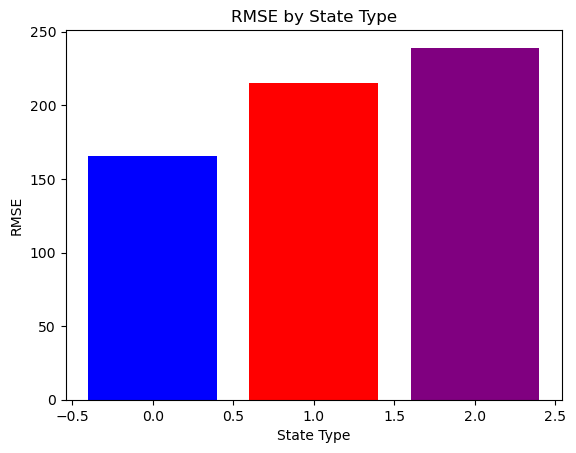


RMSE by State Type:
   State Type        RMSE
0           0  165.419725
1           1  214.863924
2           2  239.114018
R2: 0.4815
Test RMSE: 201.7907
Test MAE: 101.0032


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import f_oneway

# Load dataset
df = pd.read_csv('processed_data/100k_population_data.csv', low_memory=False)

# Exclude territories
territories_to_exclude = ['US_GU', 'US_VI', 'US_AS', 'US_PR', 'US_MP', 'US_DC']
df = df[~df['location_key'].isin(territories_to_exclude)]

# Define state lists
blue_states_list = ['US_CA', 'US_ME', 'US_OR', 'US_CO', 'US_MD', 'US_RI', 'US_CT', 'US_MA', 'US_VT', 'US_DE', 'US_NH', 'US_VA', 'US_NJ', 'US_WA', 'US_HI', 'US_NM', 'US_NY', 'US_IL']
red_states_list = ['US_AL', 'US_AK', 'US_AR', 'US_ID', 'US_IN', 'US_IA', 'US_KS', 'US_KY', 'US_LA', 'US_MS', 'US_MO', 'US_MT', 'US_NE', 'US_ND', 'US_OK', 'US_SC', 'US_SD', 'US_TN', 'US_TX', 'US_UT', 'US_WV', 'US_WY']
swing_states_list = ['US_AZ', 'US_NV', 'US_FL', 'US_NC', 'US_GA', 'US_OH', 'US_MI', 'US_PA', 'US_MN', 'US_WI']

# Create dummy variables for state types
df['blue_states'] = df['location_key'].apply(lambda x: 1 if x in blue_states_list else 0)
df['red_states'] = df['location_key'].apply(lambda x: 1 if x in red_states_list else 0)
df['swing_states'] = df['location_key'].apply(lambda x: 1 if x in swing_states_list else 0)

# Create a state_type column
def get_state_type(row):
    if row['blue_states'] == 1:
        return 'Blue'
    elif row['red_states'] == 1:
        return 'Red'
    elif row['swing_states'] == 1:
        return 'Swing'
    else:
        return 'Other'

df['state_type'] = df.apply(get_state_type, axis=1)

# Drop unneeded columns
columns_to_drop = ['blue_states', 'red_states', 'swing_states', 'target_end_date', 'location_key', 'location', 'new_hospitalized_patients', 'hospitalized_per_100k', 'unemployment_rate', 'year']
df = df.drop(columns=columns_to_drop)

# Fill missing values
df.fillna(df.mean(numeric_only=True), inplace=True)

# Define strata
strata = df['state_type'].unique()

# Perform stratified sampling
sample_df = pd.DataFrame(columns=df.columns)
for stratum in strata:
    stratum_df = df[df['state_type'] == stratum]
    stratum_size = int(0.8 * len(stratum_df))
    stratum_sample = stratum_df.sample(n=stratum_size, random_state=42)
    sample_df = pd.concat([sample_df, stratum_sample])

# Define encode_state_type function
def encode_state_type(state):
    if state == 'Blue':
        return 0
    elif state == 'Red':
        return 1
    else: 
        return 2  # For Swing states

sample_df['state_type'] = sample_df['state_type'].apply(encode_state_type)

# Split data into features (X) and target variable (y)
X = sample_df.drop(columns=['cases_per_100k', 'total_population', 'inc cases'])
y = sample_df['cases_per_100k']  

# Training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# Custom loss function with adjustable penalties
def custom_loss(y_true, y_pred, state_type, penalties):
    residuals = y_true - y_pred
    blue_penalty = (state_type == 0) * penalties[0]
    red_penalty = (state_type == 1) * penalties[1]
    swing_penalty = (state_type == 2) * penalties[2]
    weighted_residuals = residuals + blue_penalty + red_penalty + swing_penalty
    return np.mean(weighted_residuals**2)

# Train RandomForestRegressor
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

# Function to iteratively find the best penalties
def find_optimal_penalties(X_train, y_train, X_test, y_test, initial_penalties, max_iter=20, learning_rate=0.02):
    penalties = initial_penalties
    for i in range(max_iter):
        rf_model.fit(X_train, y_train)
        y_pred = rf_model.predict(X_test)
        state_type_test = X_test['state_type']
        
        rmse_blue = np.sqrt(mean_squared_error(y_test[state_type_test == 0], y_pred[state_type_test == 0]))
        rmse_red = np.sqrt(mean_squared_error(y_test[state_type_test == 1], y_pred[state_type_test == 1]))
        rmse_swing = np.sqrt(mean_squared_error(y_test[state_type_test == 2], y_pred[state_type_test == 2]))
        
        print(f"Iteration {i+1}: RMSE by State Type: Blue: {rmse_blue}, Red: {rmse_red}, Swing: {rmse_swing}")
        
        if rmse_blue > rmse_red:
            penalties[0] -= learning_rate
        else:
            penalties[0] += learning_rate
        
        if rmse_red > rmse_swing:
            penalties[1] -= learning_rate
        else:
            penalties[1] += learning_rate
        
        if rmse_swing > rmse_blue:
            penalties[2] -= learning_rate
        else:
            penalties[2] += learning_rate
    
    return penalties

# Initial penalties
initial_penalties = [1.2, 1.0, 1.1]

# Find optimal penalties
optimal_penalties = find_optimal_penalties(X_train, y_train, X_test, y_test, initial_penalties)

# Apply optimal penalties
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
state_type_test = X_test['state_type']
custom_rmse = np.sqrt(custom_loss(y_test, y_pred, state_type_test, optimal_penalties))

print(f'Custom RMSE: {custom_rmse:.4f}')

# Create DataFrame with actual and predicted values
y_test_df = pd.DataFrame({
    'cases_per_100k': y_test,
    'state_type': state_type_test,
    'predicted': y_pred
})

# Calculate RMSE by state type
def calculate_rmse(group):
    return np.sqrt(mean_squared_error(group['cases_per_100k'], group['predicted']))

rmse_by_state_type = y_test_df.groupby('state_type').apply(calculate_rmse).reset_index()
rmse_by_state_type.columns = ['State Type', 'RMSE']

# Plot RMSE by state type
plt.bar(rmse_by_state_type['State Type'], rmse_by_state_type['RMSE'], color=['blue', 'red', 'purple'])
plt.xlabel('State Type')
plt.ylabel('RMSE')
plt.title('RMSE by State Type')
plt.show()

# Print RMSE by state type
print("\nRMSE by State Type:")
print(rmse_by_state_type)

# Evaluate model
r2 = rf_model.score(X_test, y_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f'R2: {r2:.4f}')
print(f'Test RMSE: {rmse:.4f}')
print(f'Test MAE: {mae:.4f}')